# Balmorel post-processing: demand, capacity, dispatch, curtailment, costs and emissions
Post-processing backbone built on [pybalmorel](https://github.com/balmorelcommunity/pybalmorel/blob/master/examples/PostProcessing.ipynb).
It reads `MainResults.gdx` of one run and analyses:

1. Total demand for electricity, heat, hydrogen and EV charging (`EL_DEMAND_YCR`, `H_DEMAND_YCRA`, `H2_DEMAND_YCR`, TWh)
2. Total capacity mix (`G_CAP_YCRAF`, GW)
3. Total energy dispatched mix (`PRO_YCRAGF`, TWh)
4. Curtailment (`CURT_YCRAGF`, TWh)
5. Total costs (`OBJ_YCR`, Mmoney)
6. Total CO2 emissions (`EMI_YCRAG`, kton)

**Kernel:** use the `pybalmorel` conda environment. Edit the settings cell, then run the cells from the top.

In [24]:
# 0.1 Settings: point these at the run you want to post-process
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

RUN_DIR  = Path(r"C:\Balmorel\base_no_dc_8\model")   # folder containing the results GDX
RESULTS  = "MainResults_1.gdx"                          # results file name
SCENARIO = "base_no_dc_8"                               # label used for this run

import pandas as pd
import matplotlib.pyplot as plt
from pybalmorel import MainResults

res = MainResults(files=RESULTS, paths=str(RUN_DIR), scenario_names=[SCENARIO])

Loading C:\Balmorel\base_no_dc_8\model\MainResults_1.gdx


In [25]:
# 0.2 Helpers shared by all sections

# pybalmorel returns some symbols with the raw GAMS column names; map them to one naming scheme
RENAME = {"Y": "Year", "C": "Country", "RRR": "Region", "AAA": "Area", "G": "Generation", "FFF": "Fuel",
          "TECH_TYPE": "Technology", "COMMODITY": "Commodity", "CATEGORY": "Category",
          "SUBCATEGORY": "Subcategory", "UNITS": "Unit"}

def get(symbol):
    """Result symbol for SCENARIO as a DataFrame with standard column names."""
    df = res.get_result(symbol).rename(columns=RENAME)
    return df[df["Scenario"] == SCENARIO]

# Technology types folded into groups (8 colours + grey for anything else)
TECH_GROUP = {
    "WIND-ON": "Wind", "WIND-OFF": "Wind",
    "SOLAR-PV": "Solar", "SOLAR-HEATING": "Solar",
    "HYDRO-RESERVOIRS": "Hydro", "HYDRO-RUN-OF-RIVER": "Hydro",
    "CHP-BACK-PRESSURE": "CHP", "CHP-EXTRACTION": "CHP",
    "CONDENSING": "Condensing",
    "BOILERS": "Boilers",
    "ELECT-TO-HEAT": "Conversion", "ELECTROLYZER": "Conversion",
    "STEAMREFORMING": "Conversion", "BIOGASUPGRADING": "Conversion",
    "INTRASEASONAL-HEAT-STORAGE": "Storage", "INTERSEASONAL-HEAT-STORAGE": "Storage",
    "INTRASEASONAL-ELECT-STORAGE": "Storage", "H2-STORAGE": "Storage",
}
GROUP_COLORS = {"Wind": "#2a78d6", "Solar": "#eb6834", "Hydro": "#1baf7a", "CHP": "#eda100",
                "Condensing": "#e87ba4", "Boilers": "#008300", "Conversion": "#4a3aa7", "Storage": "#e34948",
                "Other": "#9a9992"}

def tech_group(df):
    return df["Technology"].map(TECH_GROUP).fillna("Other")

def stacked_bar(table, colors, title, ylabel, ax=None):
    """Stacked bar chart: one bar per row of `table` (years), one stack segment per column."""
    ax = ax or plt.subplots(figsize=(9, 4.5))[1]
    cols = [c for c in colors if c in table.columns]
    table[cols].plot.bar(stacked=True, ax=ax, color=[colors[c] for c in cols], width=0.7, edgecolor="#fcfcfb", linewidth=1)
    ax.set_title(title, loc="left"); ax.set_ylabel(ylabel); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
    for side in ("top", "right"): ax.spines[side].set_visible(False)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    return ax

def mix_by_year(df, commodity):
    """Year x technology-group table of df['Value'] for one commodity."""
    d = df[df["Commodity"] == commodity]
    return d.assign(Group=tech_group(d)).groupby(["Year", "Group"])["Value"].sum().unstack("Group").fillna(0)


# One fixed colour order for everything that is not a technology group (years, fuels, countries)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GREY = "#9a9992"

def clean_name(s):
    return str(s).replace("_", " ").title()

def country_bars(table, title, unit, n=10, ax=None):
    """Horizontal grouped bars: the n largest countries (by total over the years), one bar per year."""
    t = table.loc[table.sum(axis=1).sort_values(ascending=False).head(n).index].iloc[::-1]   # largest on top
    ax = ax or plt.subplots(figsize=(8, 5))[1]
    t.plot.barh(ax=ax, color=PALETTE[:t.shape[1]], width=0.8, edgecolor="#fcfcfb", linewidth=1)
    ax.set_yticklabels([clean_name(c) for c in t.index])
    ax.set_title(title, loc="left"); ax.set_xlabel(unit); ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)
    for side in ("top", "right"): ax.spines[side].set_visible(False)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title="Year", frameon=False, loc="lower right")
    return ax

def stacked_by_label(table, title, ylabel, n=7, ax=None):
    """Stacked bars per year; the n largest columns keep their own colour, the rest is summed as 'Other'."""
    order = table.sum().sort_values(ascending=False).index
    t = table[order[:n]].copy()
    if len(order) > n:
        t["Other"] = table[order[n:]].sum(axis=1)
    colors = dict(zip(t.columns, PALETTE[:n] + [GREY]))
    return stacked_bar(t, colors, title, ylabel, ax=ax)


## 1. Total demand
Annual demand per carrier, split by the `Category` column of each result:
`EXOGENOUS` is the final demand given as input, the `ENDO_*` categories are demand created inside the model
(EV charging, electric heating, electrolysis, CCS, storage charging, fuel cells), and the `*_LOSSES` categories are network losses.
EV charging is part of the electricity demand (`ENDO_EV`) and is also shown on its own.

In [26]:
# 1.0 Demand categories folded into groups (shared colours across the carriers)
DEMAND_GROUP = {
    "EXOGENOUS": "Final demand",
    "ENDO_EV": "EV charging",
    "ENDOGENOUS_ELECT2HEAT": "Electric heating",
    "ENDO_H2": "Electrolysis",
    "ENDO_CCS": "CCS",
    "ENDO_INTRASTO": "Storage charging", "ENDO_INTERSTO": "Storage charging",
    "ENDO_FUELCELL": "Fuel cell / other", "ENDO_OTHERTRANS": "Fuel cell / other",
    "DIST_LOSSES": "Losses", "TRANS_LOSSES": "Losses",
}
DEMAND_COLORS = {"Final demand": "#2a78d6", "EV charging": "#eb6834", "Electric heating": "#1baf7a",
                 "Electrolysis": "#eda100", "CCS": "#e87ba4", "Storage charging": "#008300",
                 "Fuel cell / other": "#4a3aa7", "Losses": "#9a9992"}

In [27]:
# 1.1 Load and aggregate demand by carrier and category
demand_sources = {
    "Electricity": get("EL_DEMAND_YCR"),
    "Heat": get("H_DEMAND_YCRA"),
    "Hydrogen": get("H2_DEMAND_YCR"),
}

demand = {}
for name, df in demand_sources.items():
    demand[name] = (
        df.assign(Group=df["Category"].map(DEMAND_GROUP))
          .groupby(["Year", "Group"])["Value"]
          .sum()
          .unstack("Group")
          .fillna(0)
    )

ev = (
    demand_sources["Electricity"]
    .loc[lambda d: d["Category"] == "ENDO_EV"]
    .groupby("Year")["Value"]
    .sum()
    .rename("EV charging")
    .reindex(demand["Electricity"].index, fill_value=0)      # years without EV demand count as 0
)

summary_demand = pd.DataFrame({
    name: table.sum(axis=1)
    for name, table in demand.items()
})
summary_demand["EV charging (part of electricity)"] = ev

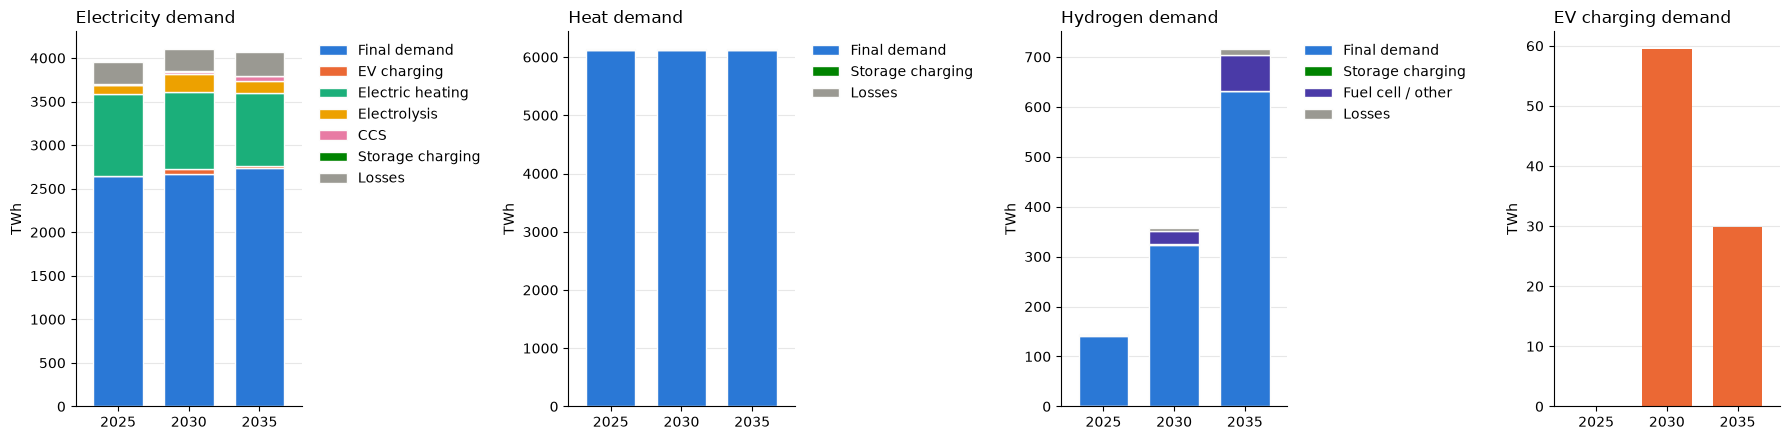

In [28]:
# 1.2 Total demand per carrier and category (TWh), plus EV charging on its own
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (name, table) in zip(axes[:3], demand.items()):
    stacked_bar(table, DEMAND_COLORS, f"{name} demand", "TWh", ax=ax)
ev.plot.bar(ax=axes[3], color=DEMAND_COLORS["EV charging"], width=0.7)
axes[3].set_title("EV charging demand", loc="left"); axes[3].set_ylabel("TWh"); axes[3].set_xlabel("")
axes[3].tick_params(axis="x", rotation=0); axes[3].grid(axis="y", alpha=0.3); axes[3].set_axisbelow(True)
for side in ("top", "right"): axes[3].spines[side].set_visible(False)
plt.tight_layout(); plt.show()

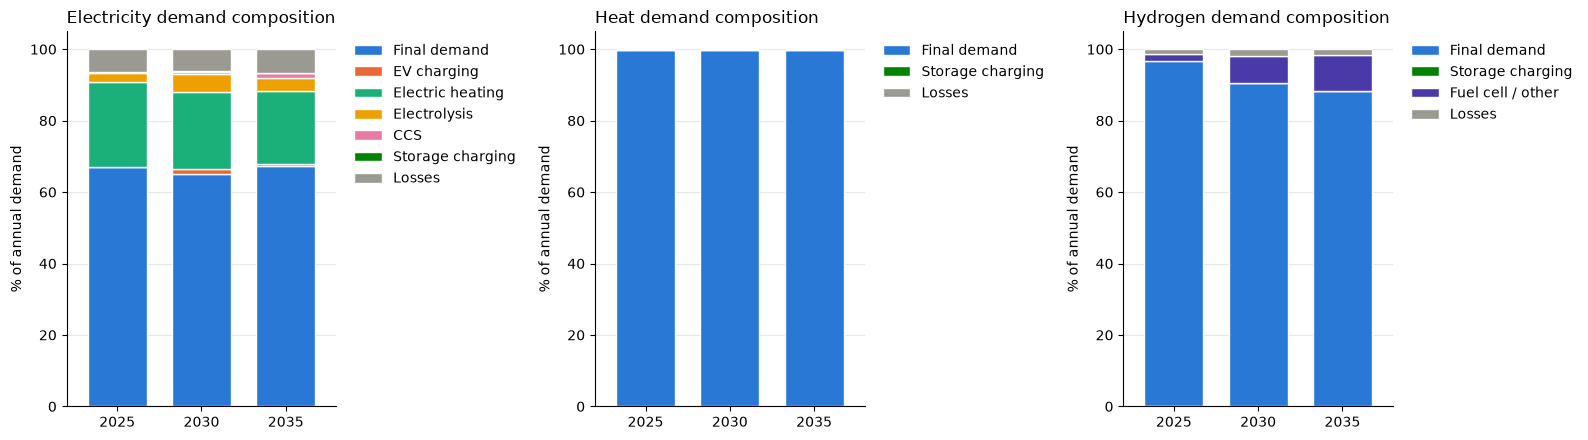

In [29]:
# 1.3 Demand composition (% of each carrier's annual demand)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, table) in zip(axes, demand.items()):
    share = table.div(table.sum(axis=1), axis=0) * 100
    stacked_bar(share, DEMAND_COLORS, f"{name} demand composition", "% of annual demand", ax=ax)
plt.tight_layout(); plt.show()

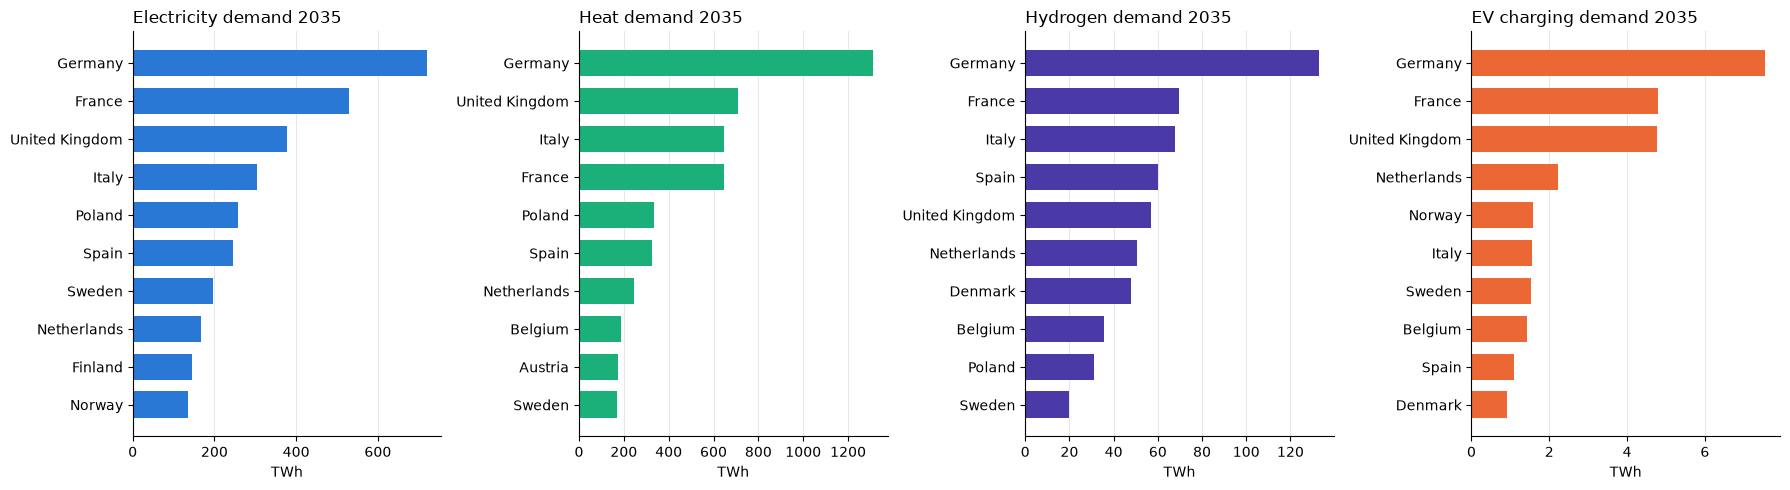

In [30]:
# 1.4 Demand per country in the last solved year (TWh): the 10 largest countries for each carrier
el_d, h_d, h2_d = get("EL_DEMAND_YCR"), get("H_DEMAND_YCRA"), get("H2_DEMAND_YCR")
last = el_d["Year"].max()
per_country = {
    "Electricity": (el_d[el_d["Year"] == last].groupby("Country")["Value"].sum(), "#2a78d6"),
    "Heat": (h_d[h_d["Year"] == last].groupby("Country")["Value"].sum(), "#1baf7a"),
    "Hydrogen": (h2_d[h2_d["Year"] == last].groupby("Country")["Value"].sum(), "#4a3aa7"),
    "EV charging": (el_d[(el_d["Year"] == last) & (el_d["Category"] == "ENDO_EV")].groupby("Country")["Value"].sum(),
                    DEMAND_COLORS["EV charging"]),
}
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, (series, color)) in zip(axes, per_country.items()):
    s = series.sort_values(ascending=False).head(10).iloc[::-1]          # largest on top
    ax.barh([clean_name(c) for c in s.index], s.values, color=color, height=0.7)
    ax.set_title(f"{name} demand {last}", loc="left"); ax.set_xlabel("TWh")
    ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)
    for side in ("top", "right"): ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Total capacity mix
`G_CAP_YCRAF` splits capacity into `EXOGENOUS` (existing / given), `ENDOGENOUS` (investments) and `DECOMMISSIONING` (negative).
The installed capacity of a year is the sum of the three. One chart per output commodity.

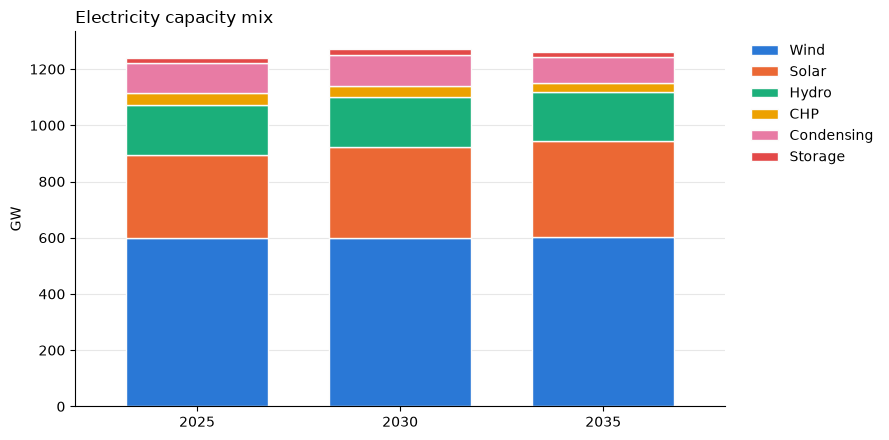

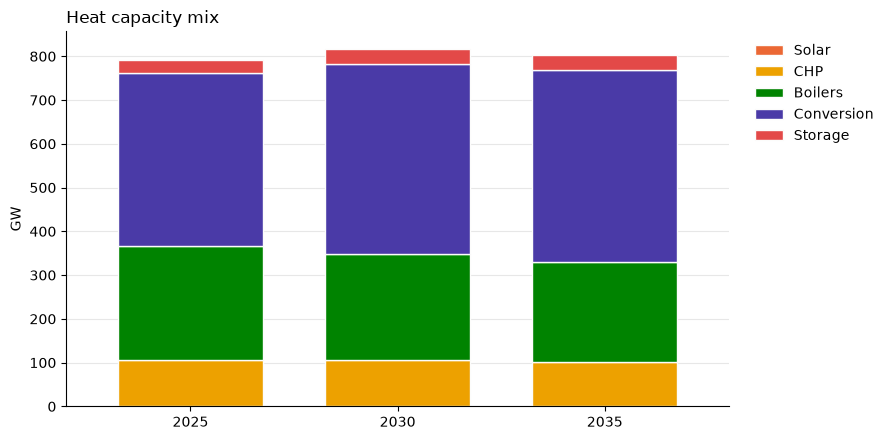

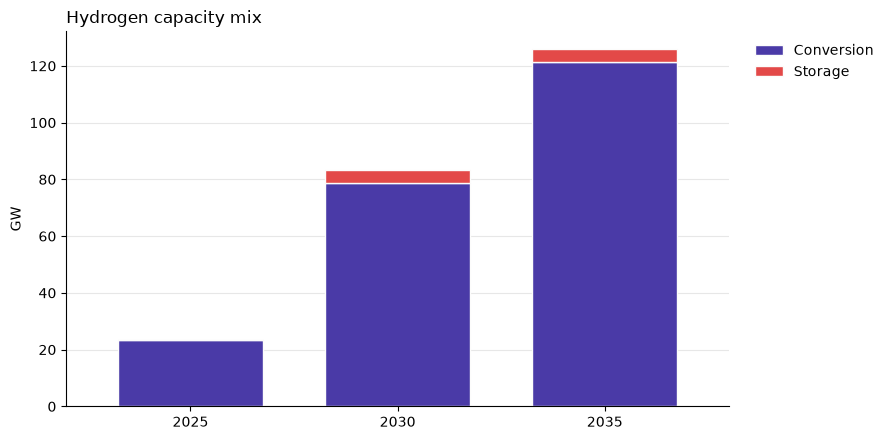

In [31]:
# 2.1 Installed capacity per year = exogenous + endogenous + decommissioning (GW)
cap = get("G_CAP_YCRAF")
for commodity in ["ELECTRICITY", "HEAT", "HYDROGEN"]:
    table = mix_by_year(cap, commodity)
    stacked_bar(table, GROUP_COLORS, f"{commodity.title()} capacity mix", "GW")
    plt.tight_layout(); plt.show()


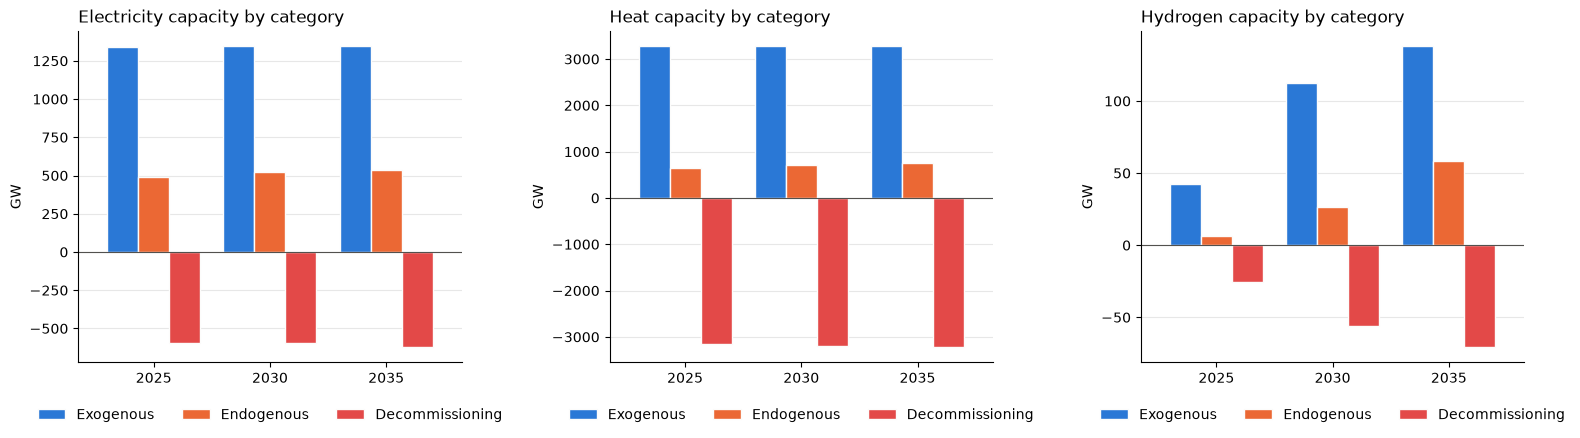

In [32]:
# 2.2 Where does the capacity come from? Exogenous, endogenous (investments) and decommissioning (GW)
CAT_COLORS = {"EXOGENOUS": "#2a78d6", "ENDOGENOUS": "#eb6834", "DECOMMISSIONING": "#e34948"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, commodity in zip(axes, ["ELECTRICITY", "HEAT", "HYDROGEN"]):
    t = cap[cap["Commodity"] == commodity].groupby(["Year", "Category"])["Value"].sum().unstack("Category").fillna(0)
    t = t[[c for c in CAT_COLORS if c in t.columns]]
    t.plot.bar(ax=ax, color=[CAT_COLORS[c] for c in t.columns], width=0.8, edgecolor="#fcfcfb", linewidth=1)
    ax.set_title(f"{commodity.title()} capacity by category", loc="left"); ax.set_ylabel("GW"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
    for side in ("top", "right"): ax.spines[side].set_visible(False)
    ax.legend([clean_name(c) for c in t.columns], frameon=False, loc="upper center",
              bbox_to_anchor=(0.5, -0.1), ncol=3)
    ax.axhline(0, color="#52514e", linewidth=0.8)          # zero line drawn after the legend exists
plt.tight_layout(); plt.show()

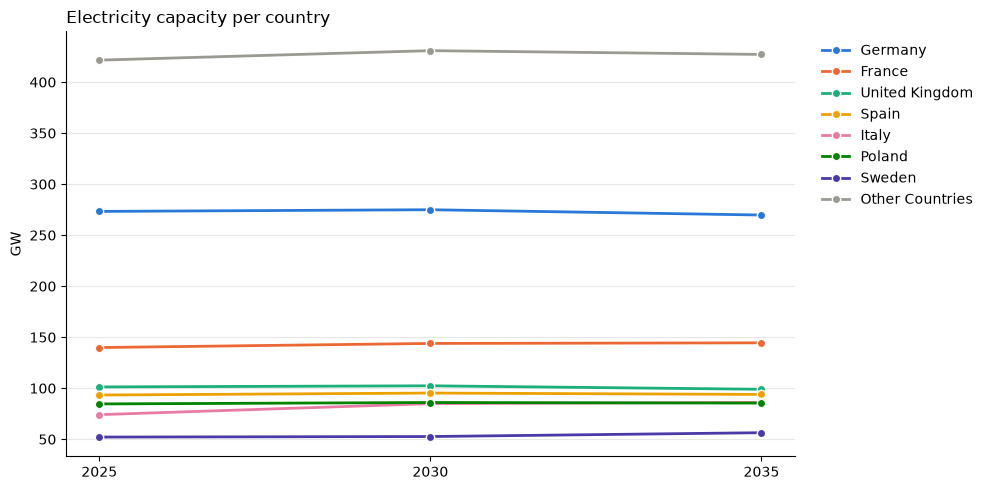

In [33]:
# 2.3 Electricity capacity per country (GW): line plot of the 7 largest countries, the rest summed as "Other countries"
cap_el = cap[cap["Commodity"] == "ELECTRICITY"]
by_country = cap_el.groupby(["Country", "Year"])["Value"].sum().unstack("Year").fillna(0)
by_country = by_country.sort_values(by_country.columns[-1], ascending=False)

other = by_country.iloc[7:].sum().to_frame("Other countries").T
plot_df = pd.concat([by_country.head(7), other]).T            # rows = years, columns = lines

palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#9a9992"]
fig, ax = plt.subplots(figsize=(10, 5))
for name, color in zip(plot_df.columns, palette):
    ax.plot(plot_df.index, plot_df[name], marker="o", markersize=6, linewidth=2, color=color,
            markeredgecolor="#fcfcfb", label=name.replace("_", " ").title())
ax.set_title("Electricity capacity per country", loc="left")
ax.set_ylabel("GW"); ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout(); plt.show()


## 3. Total energy dispatched mix
`PRO_YCRAGF` is the annual production per generator (TWh), split by output commodity.

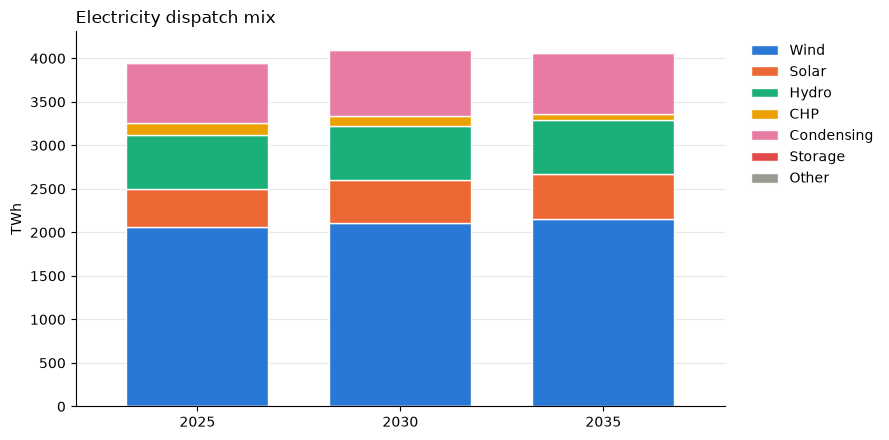

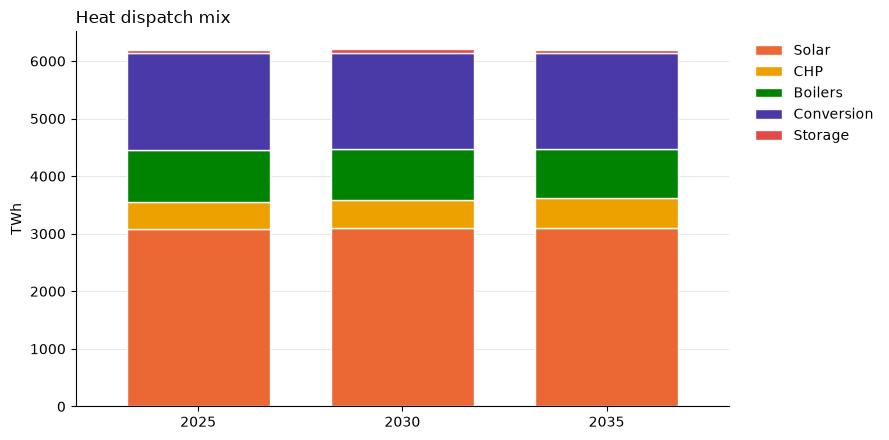

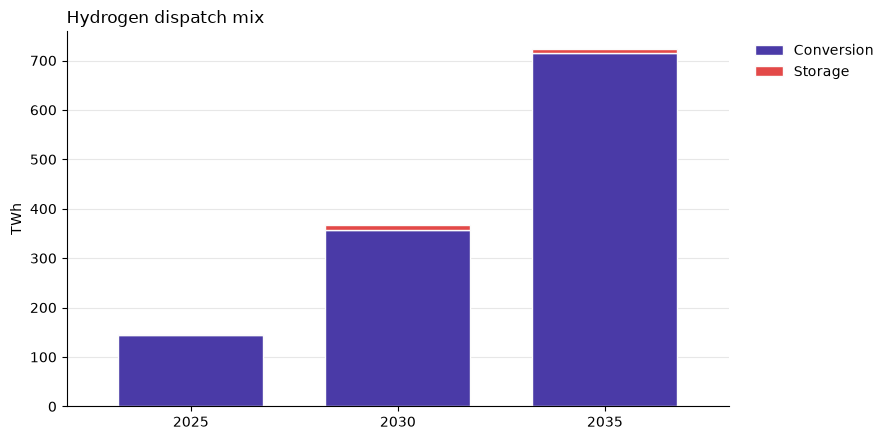

In [34]:
# 3.1 Annual production by technology group (TWh) for each commodity
pro = get("PRO_YCRAGF")
for commodity in ["ELECTRICITY", "HEAT", "HYDROGEN"]:
    table = mix_by_year(pro, commodity)
    stacked_bar(table, GROUP_COLORS, f"{commodity.title()} dispatch mix", "TWh")
    plt.tight_layout(); plt.show()


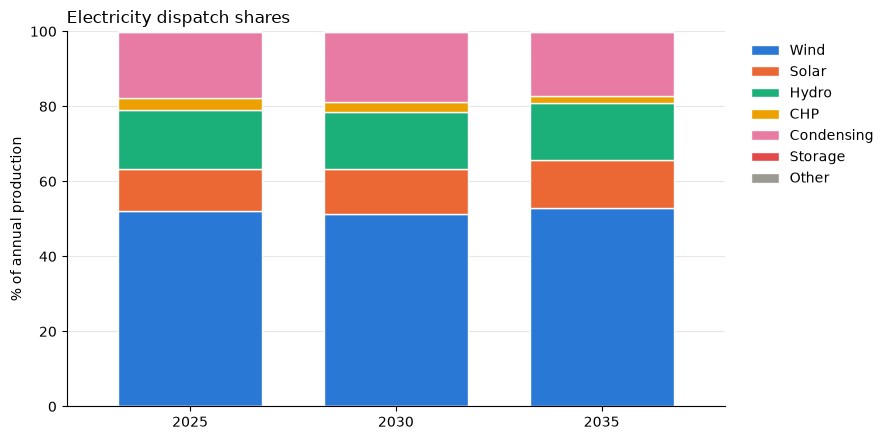

In [35]:
# 3.2 Electricity dispatch shares (% of annual electricity production)
el = mix_by_year(pro, "ELECTRICITY")
stacked_bar(el.div(el.sum(axis=1), axis=0) * 100, GROUP_COLORS, "Electricity dispatch shares", "% of annual production")
plt.tight_layout(); plt.show()

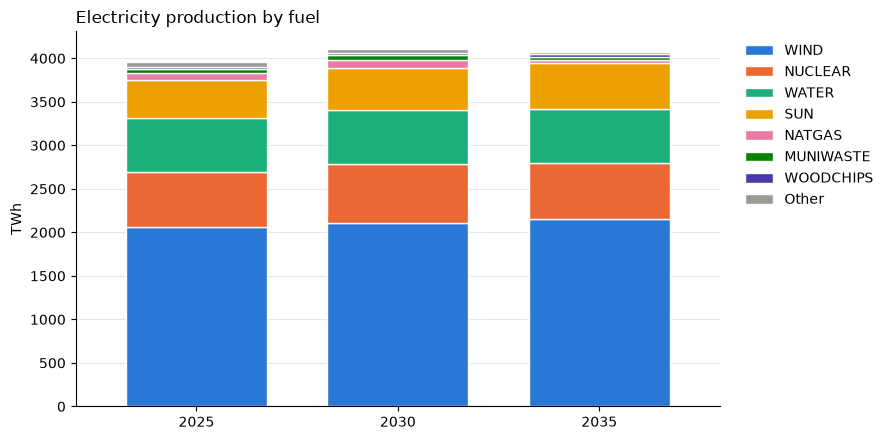

In [36]:
# 3.3 Electricity production by fuel (TWh): the 7 largest fuels, the rest summed as "Other"
fuel = pro[pro["Commodity"] == "ELECTRICITY"].groupby(["Year", "Fuel"])["Value"].sum().unstack("Fuel").fillna(0)
stacked_by_label(fuel, "Electricity production by fuel", "TWh")
plt.tight_layout(); plt.show()

## 4. Curtailment
`CURT_YCRAGF` gives the curtailed energy per generator (TWh). Wind and solar values are positive curtailment.
Hydro-reservoir rows contain entries of both signs that net to about zero (reservoir balancing), so they do not add curtailment.

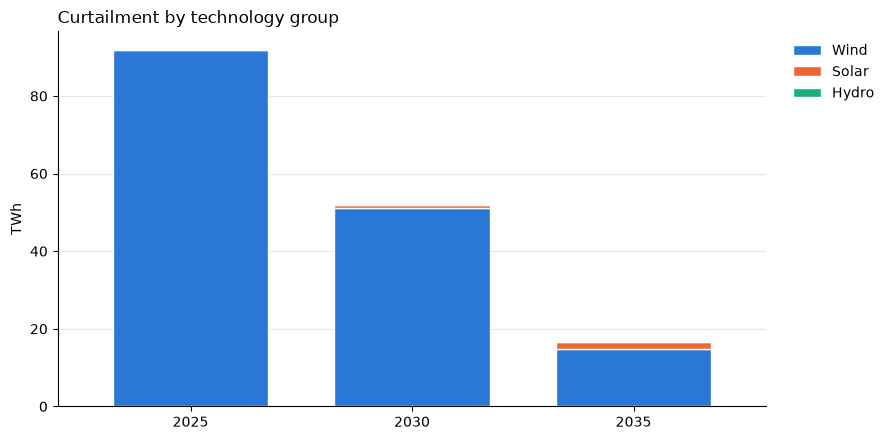

In [37]:
# 4.1 Curtailed energy by technology group (TWh)
curt = get("CURT_YCRAGF")
table = curt.assign(Group=tech_group(curt)).groupby(["Year", "Group"])["Value"].sum().unstack("Group").fillna(0)
stacked_bar(table, GROUP_COLORS, "Curtailment by technology group", "TWh")
plt.tight_layout(); plt.show()


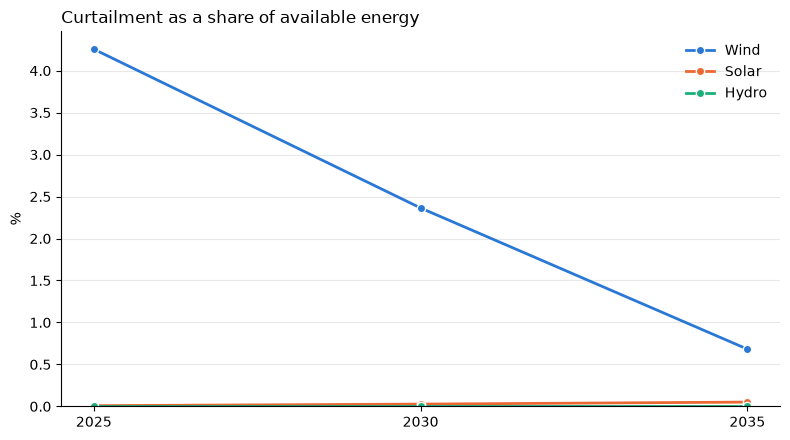

In [38]:
# 4.2 Curtailment as a share of the available energy (dispatched + curtailed), per technology group
prod_g = pro.assign(Group=tech_group(pro)).groupby(["Year", "Group"])["Value"].sum().unstack("Group").fillna(0)
share = table / (prod_g.reindex_like(table).fillna(0) + table) * 100      # `table` = curtailment by group from 4.1

fig, ax = plt.subplots(figsize=(8, 4.5))
for g in ["Wind", "Solar", "Hydro"]:
    if g in share:
        ax.plot(share.index, share[g], marker="o", markersize=6, linewidth=2, color=GROUP_COLORS[g],
                markeredgecolor="#fcfcfb", label=g)
ax.set_title("Curtailment as a share of available energy", loc="left"); ax.set_ylabel("%"); ax.set_xlabel("")
ax.set_ylim(bottom=0); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

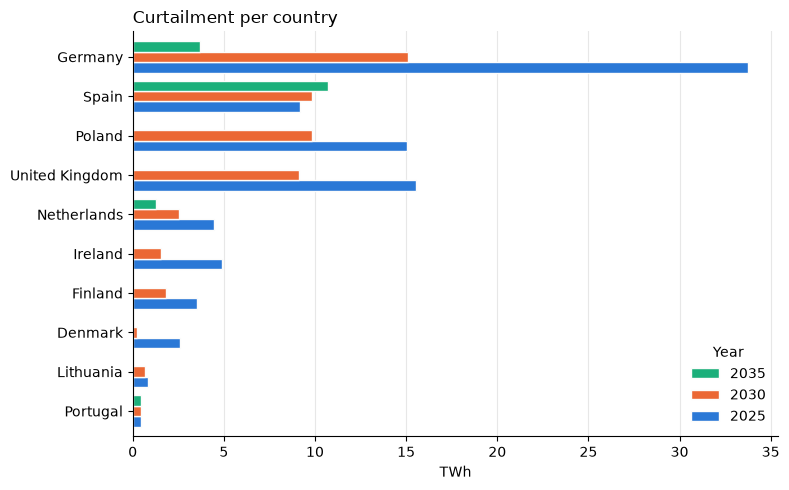

In [39]:
# 4.3 Curtailment per country (TWh): the 10 largest countries
country_bars(curt.groupby(["Country", "Year"])["Value"].sum().unstack("Year").fillna(0),
             "Curtailment per country", "TWh")
plt.tight_layout(); plt.show()

## 5. Total costs
`OBJ_YCR` holds the objective-function cost terms per year and region (Mmoney, the currency of the input data).
Cost terms are folded into five groups.

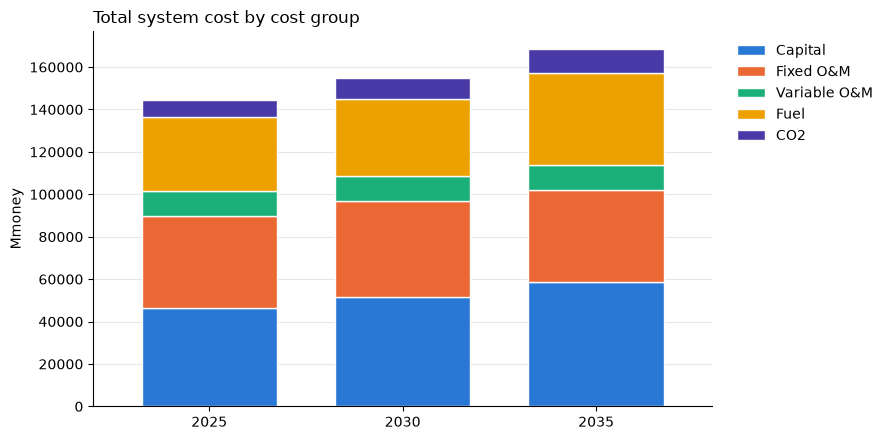

In [40]:
# 5.1 Total system cost per year and cost group (Mmoney)
obj = get("OBJ_YCR")
COST_GROUP = {
    "GENERATION_CAPITAL_COSTS": "Capital", "TRANSMISSION_CAPITAL_COSTS": "Capital", "H2_TRANSMISSION_CAPITAL_COSTS": "Capital",
    "GENERATION_FIXED_COSTS": "Fixed O&M",
    "GENERATION_OPERATIONAL_COSTS": "Variable O&M", "TRANSMISSION_OPERATIONAL_COSTS": "Variable O&M",
    "HEAT_TRANSMISSION_OPERATIONAL_COSTS": "Variable O&M", "H2_TRANSMISSION_OPERATIONAL_COSTS": "Variable O&M",
    "GENERATION_FUEL_COSTS": "Fuel",
    "GENERATION_CO2_TAX": "CO2", "GENERATION_CO2_TRANSPORT": "CO2",
}
COST_COLORS = {"Capital": "#2a78d6", "Fixed O&M": "#eb6834", "Variable O&M": "#1baf7a", "Fuel": "#eda100", "CO2": "#4a3aa7"}

costs = obj.assign(Group=obj["Category"].map(COST_GROUP).fillna("Other")) \
           .groupby(["Year", "Group"])["Value"].sum().unstack("Group").fillna(0)
stacked_bar(costs, COST_COLORS, "Total system cost by cost group", "Mmoney")
plt.tight_layout(); plt.show()


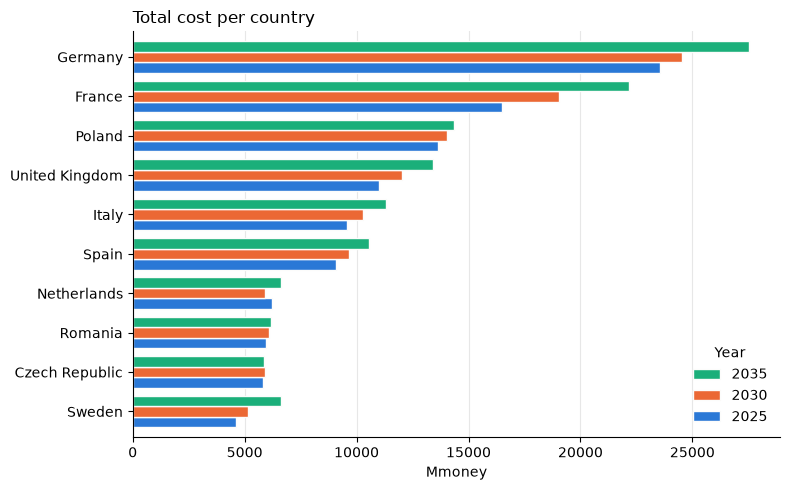

In [41]:
# 5.2 Total cost per country (Mmoney): the 10 largest countries
country_bars(obj.groupby(["Country", "Year"])["Value"].sum().unstack("Year").fillna(0),
             "Total cost per country", "Mmoney")
plt.tight_layout(); plt.show()

## 6. Total CO2 emissions
`EMI_YCRAG` holds annual CO2 emissions per generator (kton).

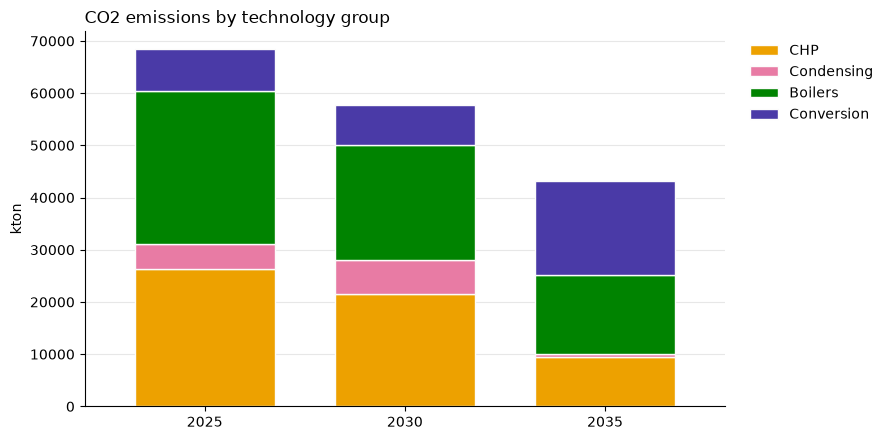

In [42]:
# 6.1 Total CO2 emissions per year by technology group (kton)
emi = get("EMI_YCRAG")
table = emi.assign(Group=tech_group(emi)).groupby(["Year", "Group"])["Value"].sum().unstack("Group").fillna(0)
stacked_bar(table, GROUP_COLORS, "CO2 emissions by technology group", "kton")
plt.tight_layout(); plt.show()


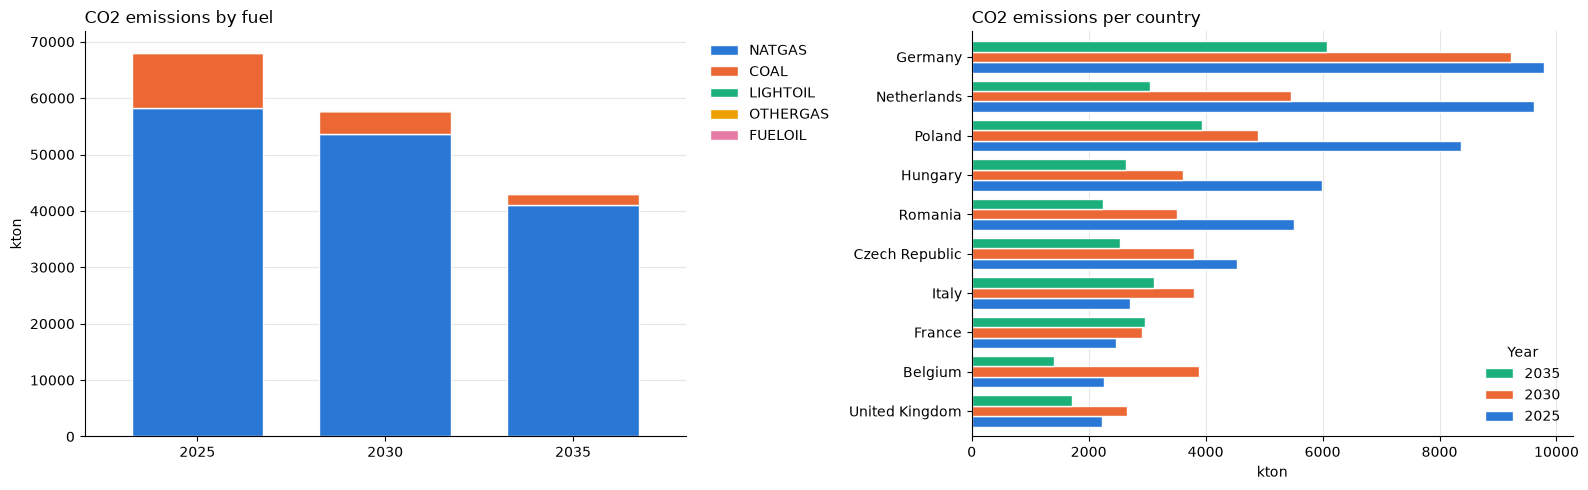

In [43]:
# 6.2 CO2 emissions by fuel (kton) and per country (kton)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fuel_e = emi.groupby(["Year", "Fuel"])["Value"].sum().unstack("Fuel").fillna(0)
stacked_by_label(fuel_e, "CO2 emissions by fuel", "kton", ax=axes[0])
country_bars(emi.groupby(["Country", "Year"])["Value"].sum().unstack("Year").fillna(0),
             "CO2 emissions per country", "kton", ax=axes[1])
plt.tight_layout(); plt.show()

In [44]:
# 6.3 Summary across the topics, per solved year
summary = pd.DataFrame({
    "Electricity demand (TWh)": summary_demand["Electricity"],
    "Heat demand (TWh)": summary_demand["Heat"],
    "Hydrogen demand (TWh)": summary_demand["Hydrogen"],
    "EV charging (TWh)": ev,
    "Electricity capacity (GW)": cap[cap["Commodity"] == "ELECTRICITY"].groupby("Year")["Value"].sum(),
    "Electricity dispatched (TWh)": pro[pro["Commodity"] == "ELECTRICITY"].groupby("Year")["Value"].sum(),
    "Curtailment (TWh)": curt.groupby("Year")["Value"].sum(),
    "Total cost (Mmoney)": obj.groupby("Year")["Value"].sum(),
    "CO2 emissions (kton)": emi.groupby("Year")["Value"].sum(),
}).round(1)


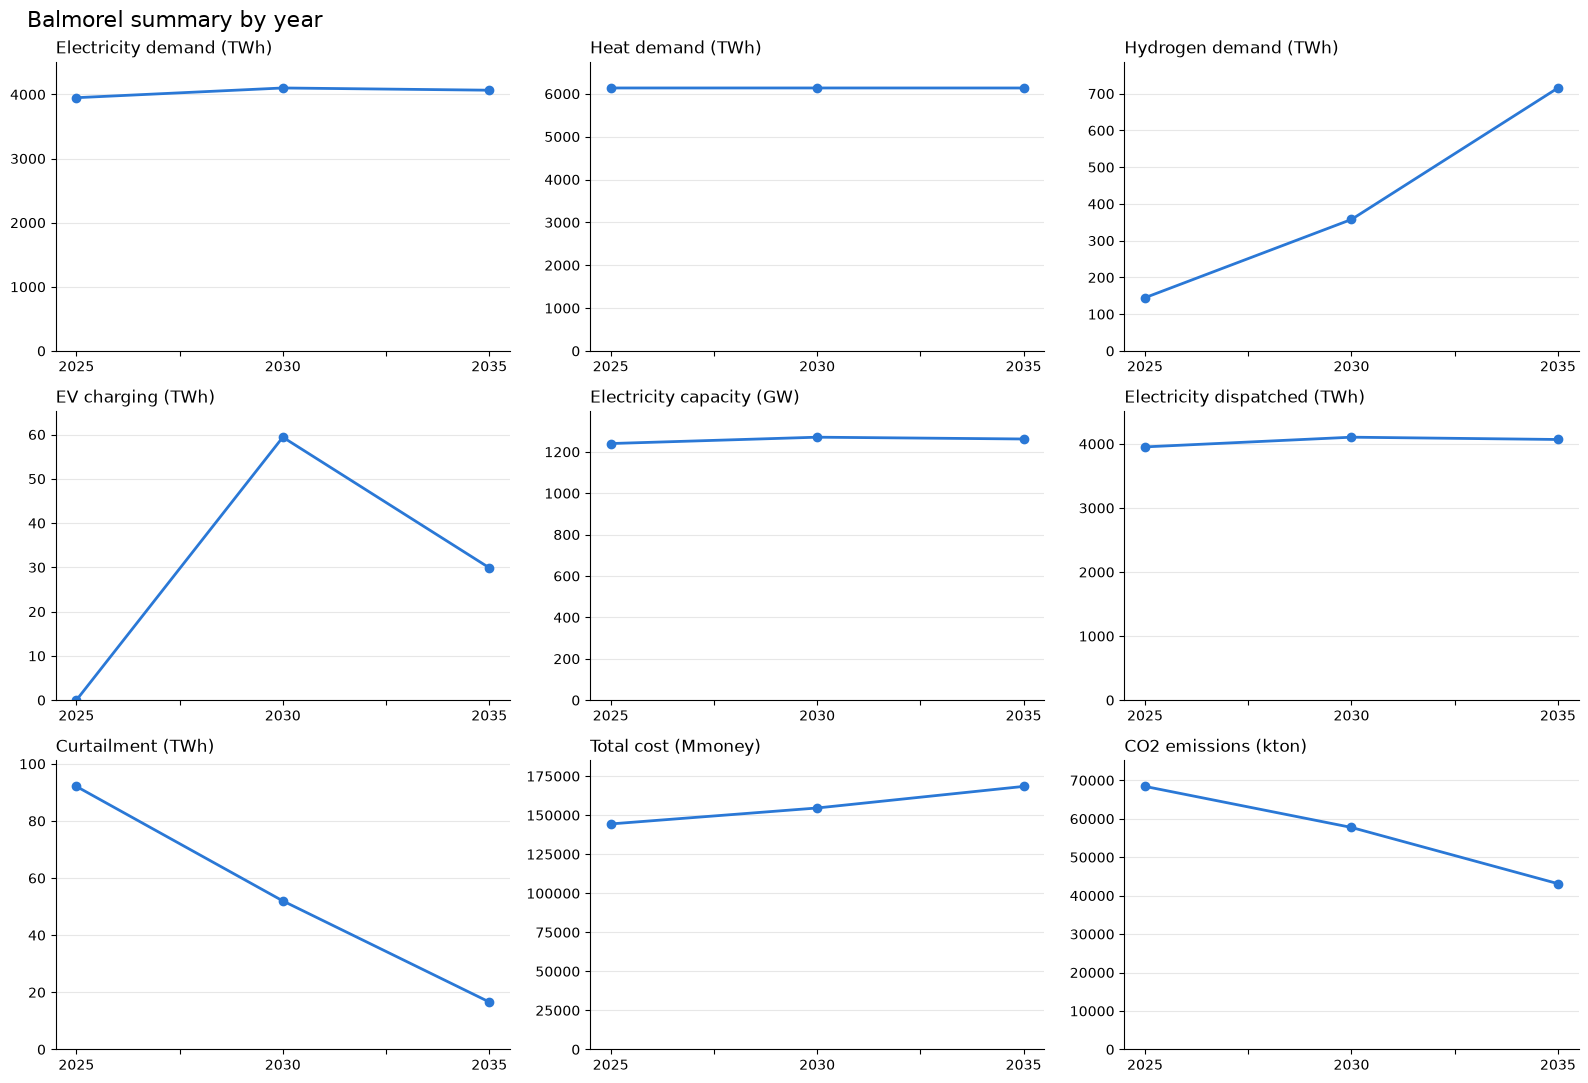

In [45]:
# Plot the summary metrics by year
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.ravel()

for ax, column in zip(axes, summary.columns):
    summary[column].plot(
        ax=ax,
        marker="o",
        linewidth=2,
        color="#2a78d6"
    )
    ax.set_ylim(0, summary[column].max() * 1.1)
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_title(column, loc="left")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

for ax in axes[len(summary.columns):]:
    ax.remove()

plt.suptitle("Balmorel summary by year", fontsize=16, x=0.02, ha="left")
plt.tight_layout()
plt.show()